## LAB 7&8 - Linear Discriminant Analysis AND Logistic Regression

## NAME: Rakshitha V S
## ROLL: 2348448

* Linear Discriminant analysis is used as a dimensionality reduction technique
in machine learning, using which we can easily transform a 2-D and 3-D
graph into a 1-dimensional plane.

* To create a new axis, Linear Discriminant Analysis uses the following
criteria:

1. It maximizes the distance between means of two classes.<br>

2.   It minimizes the variance within the individual class.


In [1]:
#importing the libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#importing the datasets
df=pd.read_csv("/content/drive/MyDrive/TRISEM 3-ML/Obesity_Classification.csv")
df

,ID,Age,Gender,Height,Weight,BMI,Label
0,1,25,Male,175,80,25.3,Normal Weight
1,2,30,Female,160,60,22.5,Normal Weight
2,3,35,Male,180,90,27.3,Overweight
3,4,40,Female,150,50,20.0,Underweight
4,5,45,Male,190,100,31.2,Obese
...,...,...,...,...,...,...,...
103,106,11,Male,175,10,3.9,Underweight
104,107,16,Female,160,10,3.9,Underweight
105,108,21,Male,180,15,5.6,Underweight
106,109,26,Female,150,15,5.6,Underweight


In [4]:
df.head(5)

,ID,Age,Gender,Height,Weight,BMI,Label
0,1,25,Male,175,80,25.3,Normal Weight
1,2,30,Female,160,60,22.5,Normal Weight
2,3,35,Male,180,90,27.3,Overweight
3,4,40,Female,150,50,20.0,Underweight
4,5,45,Male,190,100,31.2,Obese


In [5]:
df.drop(columns=["ID"],inplace=True)

In [6]:
df.describe()

,Age,Height,Weight,BMI
count,108.000000,108.000000,108.000000,108.000000
mean,46.555556,166.574074,59.490741,20.549074
std,24.720620,27.873615,28.856233,7.583818
min,11.000000,120.000000,10.000000,3.900000
25%,27.000000,140.000000,35.000000,16.700000
50%,42.500000,175.000000,55.000000,21.200000
75%,59.250000,190.000000,85.000000,26.100000
max,112.000000,210.000000,120.000000,37.200000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Age     108 non-null    int64  
 1   Gender  108 non-null    object 
 2   Height  108 non-null    int64  
 3   Weight  108 non-null    int64  
 4   BMI     108 non-null    float64
 5   Label   108 non-null    object 
dtypes: float64(1), int64(3), object(2)
memory usage: 5.2+ KB


In [8]:
df.isnull().sum()

Age       0
Gender    0
Height    0
Weight    0
BMI       0
Label     0
dtype: int64

In [9]:
df.duplicated().sum()

0

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Height'}>],
       [<Axes: title={'center': 'Weight'}>,
        <Axes: title={'center': 'BMI'}>]], dtype=object)

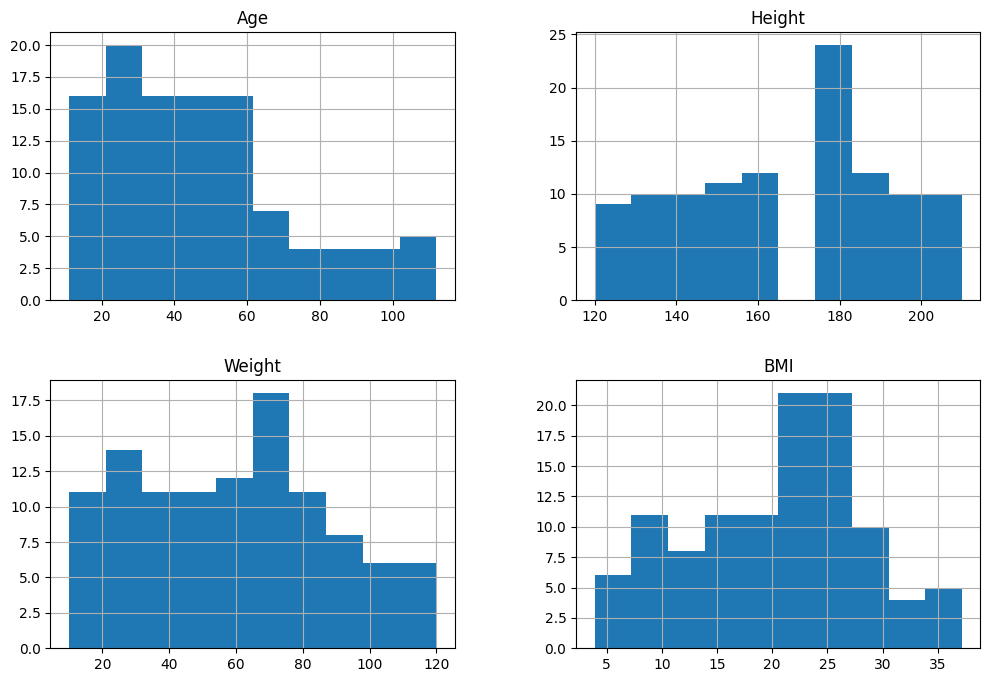

In [10]:
df.hist(figsize=(12,8))

<Axes: >

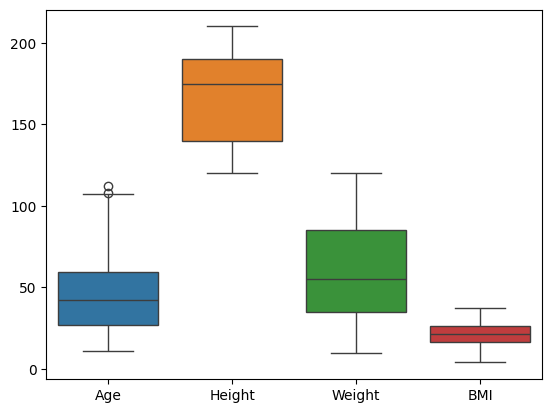

In [11]:
sns.boxplot(df)

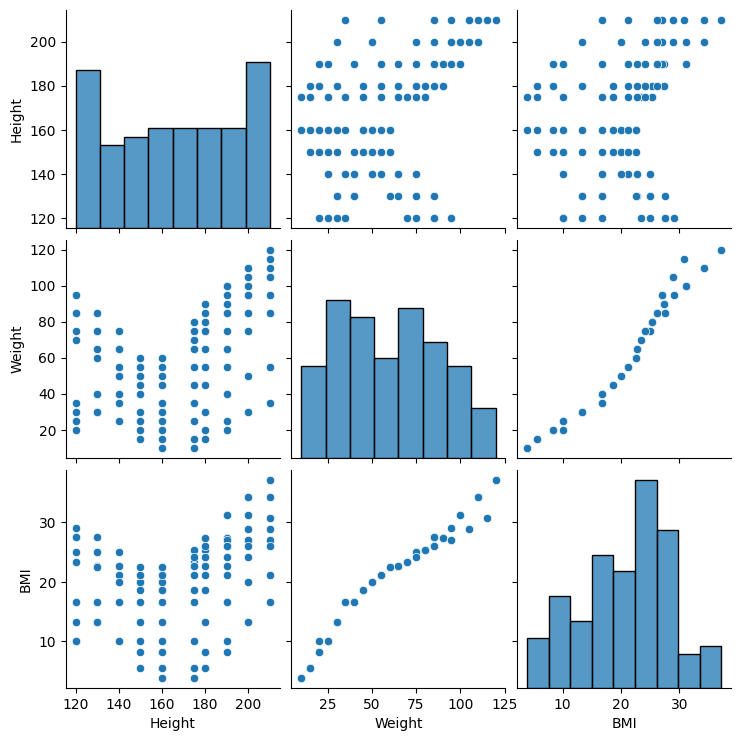

In [12]:
sns.pairplot(df.iloc[:,1:-1])

In [13]:
df["Gender"].unique()

array(['Male', 'Female'], dtype=object)

In [14]:
one=pd.get_dummies(data=df,columns=["Gender"])
one

,Age,Height,Weight,BMI,Label,Gender_Female,Gender_Male
0,25,175,80,25.3,Normal Weight,False,True
1,30,160,60,22.5,Normal Weight,True,False
2,35,180,90,27.3,Overweight,False,True
3,40,150,50,20.0,Underweight,True,False
4,45,190,100,31.2,Obese,False,True
...,...,...,...,...,...,...,...
103,11,175,10,3.9,Underweight,False,True
104,16,160,10,3.9,Underweight,True,False
105,21,180,15,5.6,Underweight,False,True
106,26,150,15,5.6,Underweight,True,False


In [15]:
from sklearn.preprocessing import OneHotEncoder
one=OneHotEncoder(sparse_output=False)

In [16]:
gen=df[["Gender"]]

In [17]:
gender=one.fit_transform(gen)

In [18]:
gender

array([[0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.

In [19]:
df1=pd.DataFrame(gender)
df1

,0,1
0,0.0,1.0
1,1.0,0.0
2,0.0,1.0
3,1.0,0.0
4,0.0,1.0
...,...,...
103,0.0,1.0
104,1.0,0.0
105,0.0,1.0
106,1.0,0.0


In [20]:
df1["Gender_M"] = df1[1]
df1

,0,1,Gender_M
0,0.0,1.0,1.0
1,1.0,0.0,0.0
2,0.0,1.0,1.0
3,1.0,0.0,0.0
4,0.0,1.0,1.0
...,...,...,...
103,0.0,1.0,1.0
104,1.0,0.0,0.0
105,0.0,1.0,1.0
106,1.0,0.0,0.0


In [21]:
df1["Gender_F"] = df1[0]
df1

,0,1,Gender_M,Gender_F
0,0.0,1.0,1.0,0.0
1,1.0,0.0,0.0,1.0
2,0.0,1.0,1.0,0.0
3,1.0,0.0,0.0,1.0
4,0.0,1.0,1.0,0.0
...,...,...,...,...
103,0.0,1.0,1.0,0.0
104,1.0,0.0,0.0,1.0
105,0.0,1.0,1.0,0.0
106,1.0,0.0,0.0,1.0


In [22]:
df1.drop([0,1],axis=1,inplace=True)

In [23]:
df1

,Gender_M,Gender_F
0,1.0,0.0
1,0.0,1.0
2,1.0,0.0
3,0.0,1.0
4,1.0,0.0
...,...,...
103,1.0,0.0
104,0.0,1.0
105,1.0,0.0
106,0.0,1.0


In [24]:
df

,Age,Gender,Height,Weight,BMI,Label
0,25,Male,175,80,25.3,Normal Weight
1,30,Female,160,60,22.5,Normal Weight
2,35,Male,180,90,27.3,Overweight
3,40,Female,150,50,20.0,Underweight
4,45,Male,190,100,31.2,Obese
...,...,...,...,...,...,...
103,11,Male,175,10,3.9,Underweight
104,16,Female,160,10,3.9,Underweight
105,21,Male,180,15,5.6,Underweight
106,26,Female,150,15,5.6,Underweight


In [25]:
df.drop(columns=["Gender"],inplace=True)

In [26]:
df

,Age,Height,Weight,BMI,Label
0,25,175,80,25.3,Normal Weight
1,30,160,60,22.5,Normal Weight
2,35,180,90,27.3,Overweight
3,40,150,50,20.0,Underweight
4,45,190,100,31.2,Obese
...,...,...,...,...,...
103,11,175,10,3.9,Underweight
104,16,160,10,3.9,Underweight
105,21,180,15,5.6,Underweight
106,26,150,15,5.6,Underweight


In [27]:
df = pd.concat([df1,df],axis=1)

In [28]:
df

,Gender_M,Gender_F,Age,Height,Weight,BMI,Label
0,1.0,0.0,25,175,80,25.3,Normal Weight
1,0.0,1.0,30,160,60,22.5,Normal Weight
2,1.0,0.0,35,180,90,27.3,Overweight
3,0.0,1.0,40,150,50,20.0,Underweight
4,1.0,0.0,45,190,100,31.2,Obese
...,...,...,...,...,...,...,...
103,1.0,0.0,11,175,10,3.9,Underweight
104,0.0,1.0,16,160,10,3.9,Underweight
105,1.0,0.0,21,180,15,5.6,Underweight
106,0.0,1.0,26,150,15,5.6,Underweight


In [29]:
df.dtypes

Gender_M    float64
Gender_F    float64
Age           int64
Height        int64
Weight        int64
BMI         float64
Label        object
dtype: object

In [30]:
X=df.iloc[:,1:6]
y=df.iloc[:,-1]

In [31]:
from sklearn.model_selection import train_test_split
## split data into train and test data set
x_train,x_test,y_train,y_test= train_test_split(X,y,test_size=0.25,random_state=0)

In [32]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
x_train_ss =  ss.fit_transform(x_train)
x_test_ss = ss.transform(x_test)


In [33]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
lda=LDA(n_components=2)
X_train_l = lda.fit_transform(x_train_ss,y_train)
X_test_l= lda.transform(x_test_ss)

In [34]:
X_train_l

array([[ 0.4005185 ,  0.42237741],
       [-0.7536478 , -0.11682332],
       [ 5.53305962, -0.19180147],
       [-3.62640036,  1.3715643 ],
       [-1.57806866, -0.88683295],
       [-2.30736486,  1.04434031],
       [-3.57975402, -1.80871529],
       [-3.35236158, -2.00144063],
       [-3.19402657, -0.32562637],
       [-3.0146485 , -0.58498862],
       [ 5.58988179, -0.97488812],
       [-1.92129708,  0.24834735],
       [-0.64374877, -0.73607492],
       [-0.80443004,  0.92059949],
       [-2.25931575,  0.02990666],
       [ 0.64818647,  0.88907797],
       [-0.18375601, -0.15091816],
       [-3.02840664, -1.29321118],
       [ 3.1665354 ,  0.10243118],
       [-0.78040549,  0.41338266],
       [ 4.47480952,  0.46590636],
       [-1.38362925,  0.7904368 ],
       [-2.29369919,  0.92939456],
       [ 1.76538789,  0.97635152],
       [ 0.26386179,  1.57183499],
       [-2.25327583,  0.28424282],
       [ 0.78484318, -0.2603796 ],
       [-3.32718634, -1.57403932],
       [ 6.41721206,

In [35]:
from sklearn.linear_model import LogisticRegression
classifier=LogisticRegression(random_state=0)
classifier.fit(X_train_l,y_train)
y_pred=classifier.predict(X_test_l)
y_pred

array(['Underweight', 'Normal Weight', 'Normal Weight', 'Overweight',
       'Overweight', 'Underweight', 'Underweight', 'Underweight',
       'Overweight', 'Underweight', 'Underweight', 'Overweight',
       'Normal Weight', 'Normal Weight', 'Overweight', 'Overweight',
       'Normal Weight', 'Underweight', 'Underweight', 'Obese',
       'Underweight', 'Obese', 'Obese', 'Underweight', 'Normal Weight',
       'Underweight', 'Obese'], dtype=object)

In [36]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[ 4  0  0  0]
 [ 0  2  2  0]
 [ 2  2  4  0]
 [ 0  0  0 11]]


In [37]:
from sklearn.metrics import accuracy_score
acc=accuracy_score(y_test,y_pred)
print("Accuracy=", acc*100, '%')

Accuracy= 77.77777777777779 %


# Logistic Regression

In [38]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train,y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [39]:
predict=lr.predict(x_test)
predict

array(['Underweight', 'Normal Weight', 'Normal Weight', 'Overweight',
       'Overweight', 'Underweight', 'Underweight', 'Underweight',
       'Overweight', 'Underweight', 'Underweight', 'Overweight',
       'Overweight', 'Normal Weight', 'Normal Weight', 'Normal Weight',
       'Normal Weight', 'Normal Weight', 'Underweight', 'Obese',
       'Underweight', 'Overweight', 'Overweight', 'Underweight',
       'Overweight', 'Normal Weight', 'Obese'], dtype=object)

In [40]:
from sklearn.metrics import classification_report
print(classification_report(y_test,predict))

               precision    recall  f1-score   support

Normal Weight       0.50      1.00      0.67         4
        Obese       0.00      0.00      0.00         4
   Overweight       0.50      0.50      0.50         8
  Underweight       1.00      0.82      0.90        11

     accuracy                           0.63        27
    macro avg       0.50      0.58      0.52        27
 weighted avg       0.63      0.63      0.61        27

